In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd

base = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings_finetuned')
h5_files = sorted(base.glob('*.h5'))

print(f'Found {len(h5_files)} HDF5 files:')
for f in h5_files:
    print(' -', f.name)

Found 57 HDF5 files:
 - berts_finetuned_full_with_metadata_altare.h5
 - berts_finetuned_full_with_metadata_ara.h5
 - berts_finetuned_full_with_metadata_basilica.h5
 - berts_finetuned_full_with_metadata_beatus.h5
 - berts_finetuned_full_with_metadata_caritas.h5
 - berts_finetuned_full_with_metadata_caro.h5
 - berts_finetuned_full_with_metadata_codex.h5
 - berts_finetuned_full_with_metadata_communico.h5
 - berts_finetuned_full_with_metadata_communio.h5
 - berts_finetuned_full_with_metadata_confessio.h5
 - berts_finetuned_full_with_metadata_confiteri.h5
 - berts_finetuned_full_with_metadata_conuersio.h5
 - berts_finetuned_full_with_metadata_conuerto.h5
 - berts_finetuned_full_with_metadata_credo.h5
 - berts_finetuned_full_with_metadata_culpa.h5
 - berts_finetuned_full_with_metadata_cultus.h5
 - berts_finetuned_full_with_metadata_deus.h5
 - berts_finetuned_full_with_metadata_disciplina.h5
 - berts_finetuned_full_with_metadata_dominus.h5
 - berts_finetuned_full_with_metadata_ecclesia.h5
 - 

In [2]:
# Pick one file to inspect
path = base / 'berts_finetuned_full_with_metadata_deus.h5'

if not path.exists() and h5_files:
    path = h5_files[0]

print('Using:', path)

Using: /Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/contextual_embeddings/output/single_word_embeddings_finetuned/berts_finetuned_full_with_metadata_deus.h5


In [3]:
with h5py.File(path, 'r') as f:
    group_names = list(f.keys())
    print('n_groups:', len(group_names))
    print('first 10 groups:', group_names[:10])

n_groups: 14285
first 10 groups: ['text_00003_sentence_00003', 'text_00005_sentence_00018', 'text_00005_sentence_00057', 'text_00005_sentence_00073', 'text_00006_sentence_00001', 'text_00008_sentence_00031', 'text_00010_sentence_00251', 'text_00010_sentence_00474', 'text_00010_sentence_00516', 'text_00010_sentence_00549']


In [4]:
with h5py.File(path, 'r') as f:
    group_names = list(f.keys())
    gname = group_names[0]
    g = f[gname]

    print('group:', gname)
    print('n_matched_words:', g.attrs.get('n_matched_words'))

    attr_items = {k: g.attrs[k] for k in g.attrs.keys()}
    print('attribute keys:', list(attr_items.keys())[:20])

    emb_names = [k for k in g.keys() if k.endswith('_embedding')]
    print('embedding datasets in group:', len(emb_names))
    if emb_names:
        vec = g[emb_names[0]][:]
        print('first embedding dataset:', emb_names[0])
        print('shape:', vec.shape, 'dtype:', vec.dtype)
        print('first 8 values:', np.round(vec[:8], 4))

group: text_00003_sentence_00003
n_matched_words: 1
attribute keys: ['creator', 'date_avg', 'date_range_end', 'date_range_start', 'file', 'id', 'label_ridge_f1', 'label_ridge_youden', 'label_svm_f1', 'label_svm_youden', 'manual_label', 'n_matched_words', 'percentile__ridge_logit', 'percentile_svm_logit', 'prediction_source', 'prob_ridge', 'prob_svm', 'score_ridge_logit', 'score_svm_logit', 'sentence_char_end']
embedding datasets in group: 1
first embedding dataset: word_0000_embedding
shape: (768,) dtype: float32
first 8 values: [ 0.995   0.0322 -0.0772  0.3834 -0.5749  0.6373 -0.2614 -0.1469]


In [5]:
# Build a compact table of first N groups
N = 50
rows = []

with h5py.File(path, 'r') as f:
    for gname in list(f.keys())[:N]:
        g = f[gname]
        rows.append({
            'group': gname,
            'n_matched_words': int(g.attrs.get('n_matched_words', 0)),
            'file': g.attrs.get('file', ''),
            'sentence_text': str(g.attrs.get('sentence_text', ''))[:120],
            'date_range_end': g.attrs.get('date_range_end', 'NA'),
            'pred_label': g.attrs.get('pred_label', 'NA')
        })

df = pd.DataFrame(rows)
df.head(15)

,group,n_matched_words,file,sentence_text,date_range_end,pred_label
0,text_00003_sentence_00003,1,lat_-0243_MQDQ-169.txt,"inferus an superus tibi fert deus funera , Uli...",-207,NA
1,text_00005_sentence_00018,1,lat_-0234_MQDQ-228.txt,"Ut illum di perdant , qui primus holitor caepa...",-201,NA
2,text_00005_sentence_00057,1,lat_-0234_MQDQ-228.txt,deo meo propitio meus homo est .,-201,NA
3,text_00005_sentence_00073,1,lat_-0234_MQDQ-228.txt,Deos quaeso ut adimant et patrem et matrem meos .,-201,NA
4,text_00006_sentence_00001,1,lat_-0234_MQDQ-229.txt,"summe deum regnator , quianam genus odisti ?",-201,NA
5,text_00008_sentence_00031,1,lat_-0234_MQDQ-226.txt,Oderunt di homines iniuros .,-201,NA
6,text_00010_sentence_00251,1,lat_-0218_MQDQ-323.txt,"Tantum a portu adporto bonum , tam gaudium gra...",-200,NA
7,text_00010_sentence_00474,1,lat_-0218_MQDQ-323.txt,Di dent quae uelis .,-200,NA
8,text_00010_sentence_00516,1,lat_-0218_MQDQ-323.txt,Ita me di bene ament measque mihi bene seruass...,-200,NA
9,text_00010_sentence_00549,1,lat_-0218_MQDQ-323.txt,Deos salutatum atque uxorem modo intro deuorto...,-200,NA


In [6]:
# Aggregate quick stats
df['n_matched_words'].describe()

count    50.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: n_matched_words, dtype: float64

## PCA and t-SNE Preview
Sample embedding vectors from one HDF5 file, reduce dimensions, and visualize potential clustering structure.

sampled vectors: (3000, 768)
time_slice distribution in sample: Counter({'post_180': 2414, 'pre_180': 586})


/var/folders/jd/xvx5v5v90h9cw8nds75nyybw0000gn/T/ipykernel_27956/4209582174.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(unique_labels)))


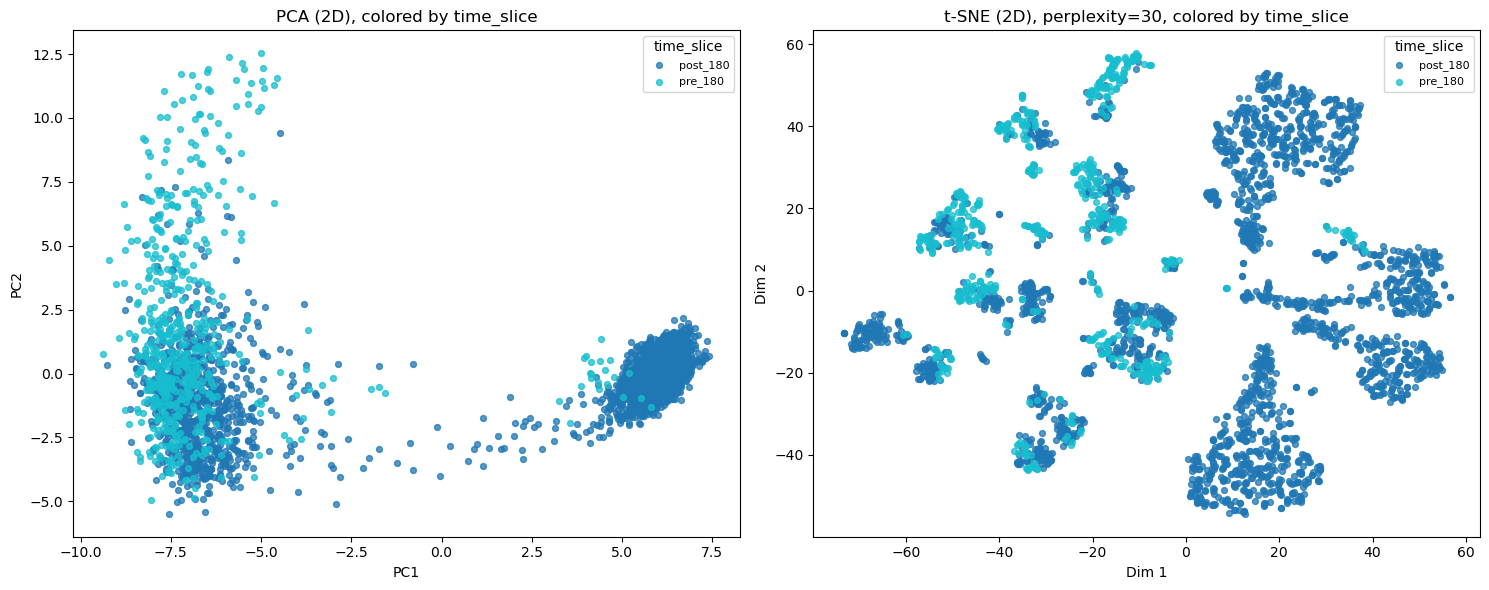

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

sample_limit = 3000
random_state = 42

vectors = []
labels = []

# choose metadata field for color coding
# options you likely have: "time_slice", "pred_label", "creator", "type"
color_by = "time_slice"

rng = random.Random(random_state)

with h5py.File(path, "r") as f:
    group_names = list(f.keys())
    rng.shuffle(group_names)  # shuffle so sample is not biased toward early (pre_180) texts

    for group_name in group_names:
        g = f[group_name]
        emb_names = [k for k in g.keys() if k.endswith("_embedding")]

        label_value = g.attrs.get(color_by)
        if label_value is None:
            label_value = g.attrs.get("pred_label", "NA")
        label_value = str(label_value)

        for emb_name in emb_names:
            vectors.append(g[emb_name][:])
            labels.append(label_value)
            if len(vectors) >= sample_limit:
                break
        if len(vectors) >= sample_limit:
            break

X = np.asarray(vectors, dtype=np.float32)
print("sampled vectors:", X.shape)
from collections import Counter
print("time_slice distribution in sample:", Counter(labels))

if X.shape[0] < 10:
    raise ValueError("Need at least 10 vectors for PCA/t-SNE preview.")

n_components_pca = 2
pca = PCA(n_components=n_components_pca, random_state=random_state)
X_pca = pca.fit_transform(X)

X_pre = PCA(n_components=min(50, X.shape[1]), random_state=random_state).fit_transform(X)
perplexity = min(30, max(5, X_pre.shape[0] // 10))
tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_pre)

unique_labels = sorted(set(labels))
label_to_idx = {label: i for i, label in enumerate(unique_labels)}
label_idx = np.array([label_to_idx[lbl] for lbl in labels])

cmap = plt.cm.get_cmap("tab10", max(1, len(unique_labels)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, label in enumerate(unique_labels):
    mask = label_idx == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=18, alpha=0.75, color=cmap(i), label=label)
axes[0].set_title(f"PCA (2D), colored by {color_by}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title=color_by, loc="best", fontsize=8)

for i, label in enumerate(unique_labels):
    mask = label_idx == i
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=18, alpha=0.75, color=cmap(i), label=label)
axes[1].set_title(f"t-SNE (2D), perplexity={perplexity}, colored by {color_by}")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].legend(title=color_by, loc="best", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:

# Map each plotted point back to file/sentence context
# Must iterate in the same shuffled order used during sampling
point_rows = []

with h5py.File(path, "r") as f:
    point_idx = 0
    for group_name in group_names:  # group_names is the shuffled list from the sampling cell
        g = f[group_name]
        emb_names = [k for k in g.keys() if k.endswith("_embedding")]
        n_matched = int(g.attrs.get("n_matched_words", 0))
        for emb_name in emb_names:
            if point_idx >= len(vectors):
                break
            point_rows.append(
                {
                    "point_idx": point_idx,
                    "group_name": group_name,
                    "embedding_name": emb_name,
                    "creator": str(g.attrs.get("creator", "NA")),
                    "title": str(g.attrs.get("title", "NA")),
                    "file": str(g.attrs.get("file", "NA")),
                    "id": str(g.attrs.get("id", "NA")),
                    "time_slice": str(g.attrs.get("time_slice", "NA")),
                    "pred_label": str(g.attrs.get("pred_label", "NA")),
                    "sentence_index": int(g.attrs.get("sentence_index", -1)),
                    "n_matched_words": n_matched,
                    "sentence_text": str(g.attrs.get("sentence_text", "")),
                    "pca_x": float(X_pca[point_idx, 0]),
                    "pca_y": float(X_pca[point_idx, 1]),
                    "tsne_x": float(X_tsne[point_idx, 0]),
                    "tsne_y": float(X_tsne[point_idx, 1]),
                }
            )
            point_idx += 1
        if point_idx >= len(vectors):
            break

points_df = pd.DataFrame(point_rows)

print("points mapped:", len(points_df))
points_df[["point_idx", "time_slice", "pred_label", "sentence_index", "n_matched_words", "sentence_text"]].head(10)


points mapped: 3000


,point_idx,time_slice,pred_label,sentence_index,sentence_text
0,0,post_180,NA,107,"Unde autem uel quis ille aut ubi deus unicus ,..."
1,1,post_180,NA,84,"uenite , ascendamus in montem domini et in dom..."
2,2,post_180,NA,933,ignotis deis . ;
3,3,post_180,NA,56,"quo abiit , profana , deus , qui dura gementem..."
4,4,post_180,NA,328,Qui nasci dignatus homo est membratur in aluo ...
5,5,post_180,NA,439,"Item , Coram deo et patre nostro in aduentu do..."
6,6,pre_180,NA,319,Uotum secundet qui potest nostrum deus rebus q...
7,7,pre_180,NA,363,Quis huic deo compararier ausit ?
8,8,post_180,NA,47,Unde intellegimusdei legem iam ante Moysen nec...
9,9,post_180,NA,3488,Non Pater adsumpsit carnem neque Spiritus sanc...


In [ ]:

# Inspect nearest contexts around a chosen point in t-SNE space

def show_neighbor_contexts(point_index=0, k=8, space="tsne"):
    if point_index not in set(points_df["point_idx"]):
        raise ValueError(f"point_index {point_index} not in dataframe")

    if space == "tsne":
        x_col, y_col = "tsne_x", "tsne_y"
    elif space == "pca":
        x_col, y_col = "pca_x", "pca_y"
    else:
        raise ValueError("space must be 'tsne' or 'pca'")

    center = points_df.loc[points_df["point_idx"] == point_index, [x_col, y_col]].iloc[0].values
    coords = points_df[[x_col, y_col]].values
    dists = np.sqrt(((coords - center) ** 2).sum(axis=1))

    out = points_df.copy()
    out["distance"] = dists
    out = out.sort_values("distance").head(k)

    cols = [
        "point_idx",
        "distance",
        "time_slice",
        "pred_label",
        "file",
        "sentence_index",
        "n_matched_words",
        "sentence_text",
    ]
    return out[cols]

# pick a point index you care about from the scatter and inspect its neighbors
show_neighbor_contexts(point_index=0, k=10, space="tsne")


,point_idx,distance,time_slice,pred_label,file,sentence_index,sentence_text
0,0,0.000000,post_180,NA,lat_0150_IT-LAT0267.txt,107,"Unde autem uel quis ille aut ubi deus unicus ,..."
2907,2907,0.397803,post_180,NA,lat_0197_IT-LAT0246.txt,912,Sed apud uos quoduis colere ius est praeter de...
656,656,0.663093,post_180,NA,lat_0150_IT-LAT0267.txt,146,"ubi deus ille , qui subuenire reuiuescentibus ..."
983,983,0.887743,pre_180,NA,lat_0121_IT-LAT0054.txt,1084,Omne frumentum deos comedisse et Caesarem esse...
223,223,1.185045,post_180,NA,lat_0300_IT-LAT0264.txt,293,"- Etiamsi esset id uerum , locis ut in superio..."
102,102,1.269407,post_180,NA,lat_0300_IT-LAT0264.txt,208,nisi forte audet quisquam - hoc enim furiosae ...
51,51,1.309788,post_180,NA,lat_0300_IT-LAT0264.txt,228,"Ergo , si haec ita sunt , Iuppiter esse deus q..."
1376,1376,1.334713,post_180,NA,lat_0300_IT-LAT0264.txt,815,"Idcirco animas misit , ut inmemores ueritatis ..."
744,744,1.351519,post_180,NA,lat_0300_IT-LAT0264.txt,1168,ad cultum diuinitatis obeundum satis est nobis...
241,241,1.466362,post_180,NA,lat_0213_IT-LAT0736.txt,241,"A nobis nec naturalia obseruantur , quasi aliu..."


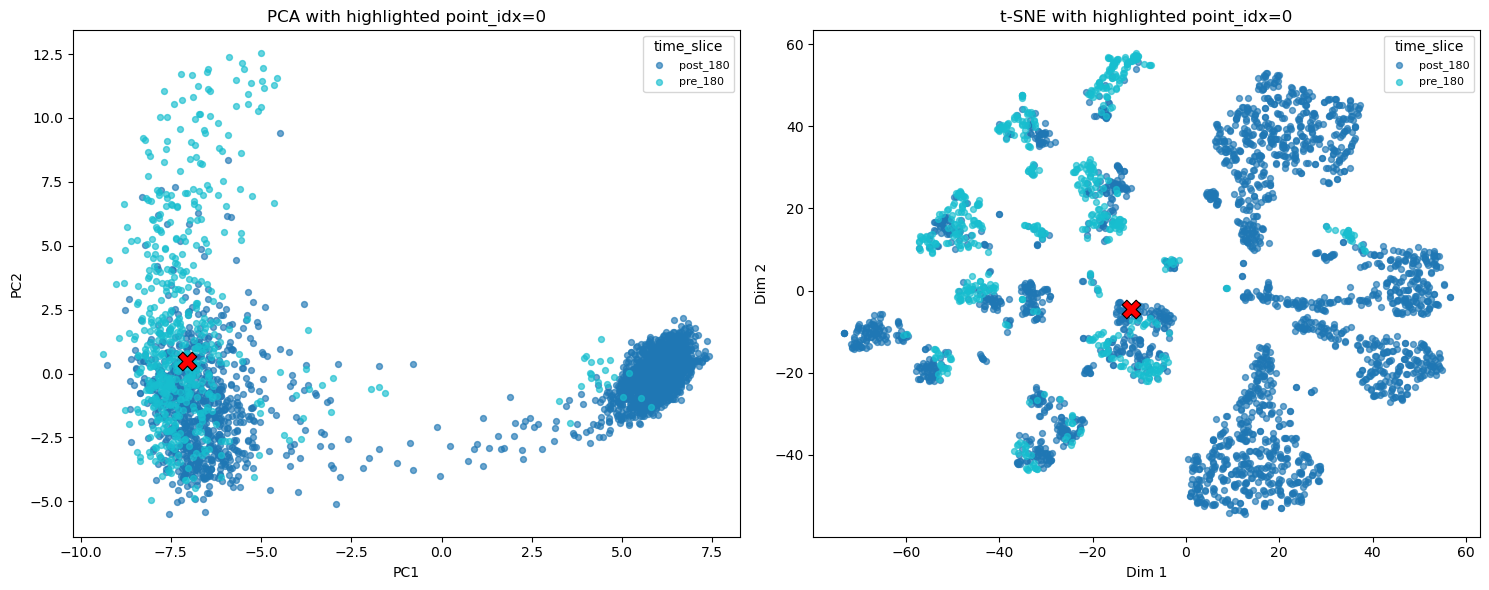

Highlighted point context:


point_idx                                                         0
time_slice                                                 post_180
pred_label                                                       NA
file                                        lat_0150_IT-LAT0267.txt
sentence_index                                                  107
sentence_text     Unde autem uel quis ille aut ubi deus unicus ,...
Name: 0, dtype: object

In [10]:
# Highlight a chosen point index on PCA/t-SNE and print its context

def plot_with_highlight(point_index=0):
    if point_index not in set(points_df["point_idx"]):
        raise ValueError(f"point_index {point_index} not found")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    unique_labels = sorted(points_df[color_by].astype(str).unique())
    cmap = plt.get_cmap("tab10", max(1, len(unique_labels)))

    for i, label in enumerate(unique_labels):
        mask = points_df[color_by].astype(str) == label
        axes[0].scatter(
            points_df.loc[mask, "pca_x"],
            points_df.loc[mask, "pca_y"],
            s=18,
            alpha=0.65,
            color=cmap(i),
            label=label,
        )

    for i, label in enumerate(unique_labels):
        mask = points_df[color_by].astype(str) == label
        axes[1].scatter(
            points_df.loc[mask, "tsne_x"],
            points_df.loc[mask, "tsne_y"],
            s=18,
            alpha=0.65,
            color=cmap(i),
            label=label,
        )

    row = points_df.loc[points_df["point_idx"] == point_index].iloc[0]

    axes[0].scatter(row["pca_x"], row["pca_y"], s=180, marker="X", color="red", edgecolor="black", linewidth=0.8)
    axes[1].scatter(row["tsne_x"], row["tsne_y"], s=180, marker="X", color="red", edgecolor="black", linewidth=0.8)

    axes[0].set_title(f"PCA with highlighted point_idx={point_index}")
    axes[1].set_title(f"t-SNE with highlighted point_idx={point_index}")

    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[1].set_xlabel("Dim 1")
    axes[1].set_ylabel("Dim 2")

    axes[0].legend(title=color_by, loc="best", fontsize=8)
    axes[1].legend(title=color_by, loc="best", fontsize=8)

    plt.tight_layout()
    plt.show()

    print("Highlighted point context:")
    display(row[["point_idx", "time_slice", "pred_label", "file", "sentence_index", "sentence_text"]])

# demo
plot_with_highlight(point_index=0)

In [11]:
# VS Code-safe interactive-ish view (no anywidget/FigureWidget dependency)
# Hover points to read `point_idx`, then use helper functions below.

import plotly.express as px
import textwrap

space = "tsne"  # "tsne" or "pca"
if space == "tsne":
    x_col, y_col = "tsne_x", "tsne_y"
else:
    x_col, y_col = "pca_x", "pca_y"

plot_df = points_df.copy()

# Wrap sentence text to ~60 chars per line, capped at 3 lines
def wrap_sentence(text, width=60, max_lines=3):
    lines = textwrap.wrap(str(text), width=width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:57] + "..."
    return "<br>".join(lines)

plot_df["sentence_wrapped"] = plot_df["sentence_text"].apply(wrap_sentence)

fig = px.scatter(
    plot_df,
    x=x_col,
    y=y_col,
    color=color_by,
    hover_name="point_idx",
    hover_data={
        "point_idx": True,
        "pred_label": True,
        "time_slice": True,
        "creator": True,
        "title": True,
        "sentence_index": True,
        "sentence_wrapped": True,
        x_col: ":.3f",
        y_col: ":.3f",
    },
    title=f"{space.upper()} plot (VS Code-safe): hover to get point_idx",
    opacity=0.8,
)

fig.update_traces(marker=dict(size=8))
fig.update_layout(
    height=560,
    width=900,
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        namelength=-1,
    ),
)
fig.show()

print("Hover a dot to read point_idx, then run:")
print("  show_neighbor_contexts(point_index=<idx>, k=10, space='tsne')")
print("or:")
print("  plot_with_highlight(point_index=<idx>)")

Hover a dot to read point_idx, then run:
  show_neighbor_contexts(point_index=<idx>, k=10, space='tsne')
or:
  plot_with_highlight(point_index=<idx>)


In [12]:
show_neighbor_contexts(point_index=304, k=10, space='tsne')

,point_idx,distance,time_slice,pred_label,file,sentence_index,sentence_text
304,304,0.000000,post_180,NA,lat_0382_IT-LAT0001.txt,8,Ezechiae et misericordiarum eius scripta sunt ...
471,471,0.312402,post_180,NA,lat_0382_IT-LAT0001.txt,8,Ezechiae et misericordiarum eius scripta sunt ...
1481,1481,0.646700,post_180,NA,lat_0382_IT-LAT0001.txt,9,illic gentem peccatorum uiros iniquos et conua...
316,316,0.713079,post_180,NA,lat_0382_IT-LAT0001.txt,8,Ezechiae et misericordiarum eius scripta sunt ...
2062,2062,0.908001,post_180,NA,lat_0382_IT-LAT0001.txt,0,in principio creauit Deus caelum et terram ter...
2008,2008,1.238576,post_180,NA,lat_0382_IT-LAT0001.txt,0,in principio creauit Deus caelum et terram ter...
2720,2720,1.536025,post_180,NA,lat_0382_IT-LAT0001.txt,23,animam tuam mendacium non reuerearis proximum ...
453,453,1.701460,post_180,NA,lat_0382_IT-LAT0001.txt,8,Ezechiae et misericordiarum eius scripta sunt ...
2796,2796,1.854677,post_180,NA,lat_0350_IT-LAT0719.txt,63,"sed non ipsa parte exire habebamus , qua intra..."
1955,1955,1.871157,post_180,NA,lat_0382_IT-LAT0001.txt,31,Exiit ergo Ihesus portans spineam coronam et p...


In [98]:
# Coverage check: how many total embeddings exist vs how many are plotted?
total_embeddings = 0
total_groups = 0

with h5py.File(path, "r") as f:
    total_groups = len(f.keys())
    for group_name in f.keys():
        g = f[group_name]
        total_embeddings += len([k for k in g.keys() if k.endswith("_embedding")])

plotted = len(points_df)
unplotted = total_embeddings - plotted

print(f"Total groups (sentences):  {total_groups}")
print(f"Total embeddings in file:  {total_embeddings}")
print(f"sample_limit:              {sample_limit}")
print(f"Points plotted:            {plotted}")
print(f"Unplotted embeddings:      {unplotted}  ({100*unplotted/total_embeddings:.1f}%)")


Total groups (sentences):  14285
Total embeddings in file:  20966
sample_limit:              3000
Points plotted:            3000
Unplotted embeddings:      17966  (85.7%)


In [86]:
# Time-slice coverage across ALL lemma files
# Shows whether imbalance is a data/production issue or simply word attestation patterns
# Terms like martyr/ecclesia being post_180-only is expected.
# Terms like uirtus/deus/fides being exclusively one slice would signal a production problem.

EXPECT_BOTH_SLICES = {"uirtus", "deus", "fides", "uita", "gloria", "lex", "dominus", "salus"}

rows = []
for h5_path in sorted(base.glob("*.h5")):
    lemma = h5_path.stem.replace("berts_finetuned_full_with_metadata_", "")
    counts = {"pre_180": 0, "post_180": 0, "NA": 0}
    n_groups = 0
    with h5py.File(h5_path, "r") as f:
        n_groups = len(f.keys())
        for gname in f.keys():
            g = f[gname]
            n_words = int(g.attrs.get("n_matched_words", 0))
            ts = str(g.attrs.get("time_slice", "NA"))
            counts[ts] = counts.get(ts, 0) + n_words
    rows.append({
        "lemma": lemma,
        "n_groups": n_groups,
        "pre_180": counts.get("pre_180", 0),
        "post_180": counts.get("post_180", 0),
        "NA": counts.get("NA", 0),
    })

coverage_df = pd.DataFrame(rows).sort_values("lemma").reset_index(drop=True)
coverage_df["total"] = coverage_df["pre_180"] + coverage_df["post_180"] + coverage_df["NA"]
coverage_df["pre_180_%"] = (coverage_df["pre_180"] / coverage_df["total"].replace(0, 1) * 100).round(1)
coverage_df["post_180_%"] = (coverage_df["post_180"] / coverage_df["total"].replace(0, 1) * 100).round(1)

only_post = coverage_df[coverage_df["pre_180"] == 0]["lemma"].tolist()
only_pre  = coverage_df[coverage_df["post_180"] == 0]["lemma"].tolist()

# Flag terms that should appear in both but don't
suspicious = [l for l in only_post + only_pre if l in EXPECT_BOTH_SLICES]

print(f"Lemmas with ONLY post_180 embeddings ({len(only_post)}): {only_post}")
print(f"Lemmas with ONLY pre_180  embeddings ({len(only_pre)}):  {only_pre}")
if suspicious:
    print(f"\n⚠️  SUSPICIOUS (expected in both slices but found in only one): {suspicious}")
else:
    print("\n✓ No unexpected single-slice lemmas among high-priority terms.")
print()
coverage_df[["lemma", "n_groups", "pre_180", "post_180", "pre_180_%", "post_180_%", "total"]]


Lemmas with ONLY post_180 embeddings (6): ['confiteri', 'ecclesia', 'martyr', 'martyrium', 'passio', 'saluator']
Lemmas with ONLY pre_180  embeddings (0):  []

✓ No unexpected single-slice lemmas among high-priority terms.



,lemma,n_groups,pre_180,post_180,pre_180_%,post_180_%,total
0,altare,90,4,425,0.9,99.1,429
1,ara,1147,718,485,59.7,40.3,1203
2,basilica,343,30,328,8.4,91.6,358
3,beatus,1498,705,960,42.3,57.7,1665
4,caritas,474,176,401,30.5,69.5,577
5,caro,1782,233,2244,9.4,90.6,2477
6,codex,198,46,160,22.3,77.7,206
7,communico,191,86,127,40.4,59.6,213
8,communio,236,82,160,33.9,66.1,242
9,confessio,261,98,182,35.0,65.0,280


In [87]:
import unicodedata
from collections import defaultdict

# Use the same metadata filter as the extraction script
metadata_file = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/data/latinise_metadata_2026_with_predictions.csv')
lemmatized_dir = Path('/Users/pinkhorse/Documents/GitHub/latinise/christianity_semantic_change/data/new_lemmatized_texts')

metadata_df = pd.read_csv(metadata_file)
metadata_df['date_range_end'] = pd.to_numeric(metadata_df['date_range_end'], errors='coerce')
metadata_df = metadata_df.dropna(subset=['date_range_end'])
metadata_df['date_range_end'] = metadata_df['date_range_end'].astype(int)
metadata_ph = metadata_df[
    (metadata_df['date_range_end'] > -300) &
    (metadata_df['date_range_end'] <= 605)
].copy()

# Only files that actually exist in the lemmatized dir and passed the filter
in_scope_files = {
    row['file'] for _, row in metadata_ph.iterrows()
    if (lemmatized_dir / row['file']).exists()
}
print(f"Total lemmatized files on disk: {len(list(lemmatized_dir.glob('*.txt')))}")
print(f"Texts passing metadata filter (date > -300 and <= 605): {len(metadata_ph)}")
print(f"Of those, files found in lemmatized_dir: {len(in_scope_files)}\n")

TARGET_LEMMAS = {
    "altare", "ara", "basilica", "beatus", "caritas", "caro", "codex",
    "communico", "communio", "confessio", "confiteor", "conuersio", "conuerto",
    "credo", "cultus", "culpa", "deus", "disciplina", "dominus",
    "fidelis", "fides", "gentilis", "gens", "gloria", "gratia", "lectio",
    "lex", "lux", "lumen", "mors", "mundus", "mysterium",
    "oratio", "ordo", "paenitentia", "paganus", "passio", "peccatum", "pontifex",
    "regula", "religio", "sacramentum", "salus", "saluator", "saluo", "saeculum",
    "sanctus", "scriptura", "spiritus", "tenebrae", "templum", "testamentum",
    "uita", "uirtus",
}

def normalize_lemma(token):
    if token is None:
        return ""
    normalized = unicodedata.normalize("NFKD", token)
    normalized = "".join(ch for ch in normalized if ch.isalpha())
    normalized = normalized.lower().replace("v", "u")
    return normalized

normalized_targets = {normalize_lemma(t) for t in TARGET_LEMMAS}

corpus_counts = defaultdict(int)
for fname in sorted(in_scope_files):
    with open(lemmatized_dir / fname, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            for token in line.split():
                norm = normalize_lemma(token)
                if norm in normalized_targets:
                    corpus_counts[norm] += 1

print(f"Counted tokens across {len(in_scope_files)} in-scope lemmatized files.\n")

# Build comparison table
compare_rows = []
for lemma in sorted(TARGET_LEMMAS):
    norm = normalize_lemma(lemma)
    corpus_n = corpus_counts.get(norm, 0)
    h5_total = None
    if 'coverage_df' in dir():
        match = coverage_df[coverage_df["lemma"] == lemma]
        h5_total = int(match["total"].iloc[0]) if len(match) > 0 else 0
    compare_rows.append({
        "lemma": lemma,
        "corpus_count": corpus_n,
        "h5_embeddings": h5_total,
    })

compare_df = pd.DataFrame(compare_rows)
if compare_df["h5_embeddings"].notna().any():
    compare_df["coverage_%"] = (compare_df["h5_embeddings"] / compare_df["corpus_count"].replace(0, 1) * 100).round(1)
    compare_df["missing"] = compare_df["corpus_count"] - compare_df["h5_embeddings"]

compare_df.sort_values("corpus_count", ascending=False).reset_index(drop=True)


Total lemmatized files on disk: 1153
Texts passing metadata filter (date > -300 and <= 605): 777
Of those, files found in lemmatized_dir: 777

Counted tokens across 777 in-scope lemmatized files.

Counted tokens across 777 in-scope lemmatized files.



,lemma,corpus_count,h5_embeddings,coverage_%,missing
0,deus,19979,20966,104.9,-987
1,dominus,14123,14272,101.1,-149
2,lex,7697,7606,98.8,91
3,credo,7285,7564,103.8,-279
4,uita,7254,7279,100.3,-25
5,mors,6466,6463,100.0,3
6,uirtus,5955,5960,100.1,-5
7,fides,5946,5916,99.5,30
8,gens,5185,0,0.0,5185
9,sanctus,4346,4258,98.0,88


In [63]:
# Check for duplicate embeddings caused by append-mode re-runs
# If a group has n_matched_words=N but more than N embedding datasets, it was written multiple times

print("Checking for duplicate embeddings in H5 files...\n")
dup_rows = []
for h5_path in sorted(base.glob("*.h5")):
    lemma = h5_path.stem.replace("berts_finetuned_full_with_metadata_", "")
    n_dup_groups = 0
    total_extra = 0
    with h5py.File(h5_path, "r") as f:
        for gname in f.keys():
            g = f[gname]
            n_matched = int(g.attrs.get("n_matched_words", 0))
            n_datasets = len([k for k in g.keys() if k.endswith("_embedding")])
            if n_datasets > n_matched:
                n_dup_groups += 1
                total_extra += n_datasets - n_matched
    if n_dup_groups > 0:
        dup_rows.append({"lemma": lemma, "groups_with_duplicates": n_dup_groups, "extra_embeddings": total_extra})

if dup_rows:
    dup_df = pd.DataFrame(dup_rows).sort_values("extra_embeddings", ascending=False)
    print(f"⚠️  {len(dup_df)} files have groups with extra (duplicate) embeddings:")
    print(dup_df.to_string(index=False))
else:
    print("✓ No duplicate embeddings found.")


Checking for duplicate embeddings in H5 files...

✓ No duplicate embeddings found.
✓ No duplicate embeddings found.
